# RET-02 Product Review Sentiment Intelligence

## Model Gate

This notebook trains a naive baseline and compares text-classification
models using validation data.

The protected test set will not be used during model selection.

In [1]:
!pip -q install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

In [3]:
df = pd.read_csv(
    "/content/amazon_cells_labelled.txt",
    sep="\t",
    header=None,
    names=["review", "label"]
)

df["review"] = df["review"].astype("string").str.strip()

df = df.dropna(subset=["review", "label"])
df = df[df["review"].ne("")]
df = df[df["label"].isin([0, 1])].copy()

conflicting_texts = (
    df.groupby("review")["label"]
    .nunique()
    .loc[lambda values: values > 1]
    .index
)

df_clean = df[
    ~df["review"].isin(conflicting_texts)
].copy()

df_clean = (
    df_clean
    .drop_duplicates(subset=["review"], keep="first")
    .reset_index(drop=True)
)

print("Cleaned rows:", len(df_clean))
print(df_clean["label"].value_counts().sort_index())

Cleaned rows: 990
label
0    497
1    493
Name: count, dtype: int64


In [4]:
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["label"],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train = train_df["review"]
y_train = train_df["label"]

X_val = val_df["review"]
y_val = val_df["label"]

X_test = test_df["review"]
y_test = test_df["label"]

print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Protected test rows:", len(test_df))

Training rows: 693
Validation rows: 148
Protected test rows: 149


In [5]:
print(
    "Train-validation overlap:",
    len(set(X_train).intersection(set(X_val)))
)

print(
    "Train-test overlap:",
    len(set(X_train).intersection(set(X_test)))
)

print(
    "Validation-test overlap:",
    len(set(X_val).intersection(set(X_test)))
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [6]:
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

start_time = time.perf_counter()

dummy_model.fit(
    X_train.to_frame(),
    y_train
)

dummy_val_predictions = dummy_model.predict(
    X_val.to_frame()
)

dummy_runtime = time.perf_counter() - start_time

dummy_accuracy = accuracy_score(
    y_val,
    dummy_val_predictions
)

dummy_macro_f1 = f1_score(
    y_val,
    dummy_val_predictions,
    average="macro",
    zero_division=0
)

print("Dummy validation accuracy:", round(dummy_accuracy, 4))
print("Dummy validation macro F1:", round(dummy_macro_f1, 4))
print("Runtime:", round(dummy_runtime, 4), "seconds")

Dummy validation accuracy: 0.5
Dummy validation macro F1: 0.3333
Runtime: 0.0058 seconds


In [7]:
print(
    classification_report(
        y_val,
        dummy_val_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67        74
    Positive       0.00      0.00      0.00        74

    accuracy                           0.50       148
   macro avg       0.25      0.50      0.33       148
weighted avg       0.25      0.50      0.33       148



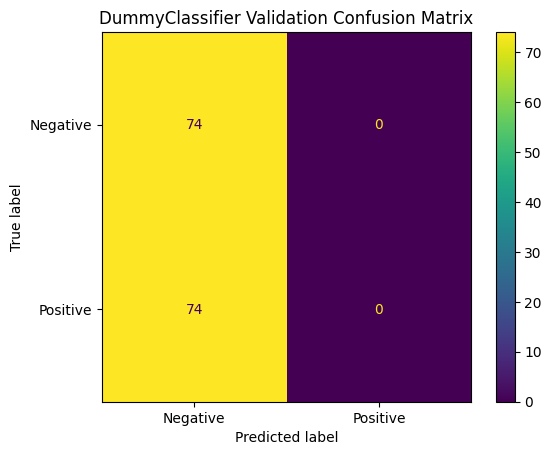

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    dummy_val_predictions,
    display_labels=["Negative", "Positive"]
)

plt.title("DummyClassifier Validation Confusion Matrix")
plt.show()

## DummyClassifier conclusion

The DummyClassifier predicted every validation review as negative.

It correctly classified all 74 negative reviews but incorrectly classified
all 74 positive reviews.

Its validation accuracy was 0.50 and its macro F1-score was approximately
0.33. This is a weak reference baseline because the model does not learn
anything from the review text.

The real text-classification models should perform clearly better than this.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [10]:
logreg_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

start_time = time.perf_counter()

logreg_pipeline.fit(
    X_train,
    y_train
)

logreg_val_predictions = logreg_pipeline.predict(
    X_val
)

logreg_runtime = time.perf_counter() - start_time

In [11]:
logreg_accuracy = accuracy_score(
    y_val,
    logreg_val_predictions
)

logreg_macro_f1 = f1_score(
    y_val,
    logreg_val_predictions,
    average="macro",
    zero_division=0
)

print(
    "Logistic Regression validation accuracy:",
    round(logreg_accuracy, 4)
)

print(
    "Logistic Regression validation macro F1:",
    round(logreg_macro_f1, 4)
)

print(
    "Runtime:",
    round(logreg_runtime, 4),
    "seconds"
)

Logistic Regression validation accuracy: 0.8311
Logistic Regression validation macro F1: 0.8309
Runtime: 0.1432 seconds


In [12]:
print(
    classification_report(
        y_val,
        logreg_val_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.81      0.86      0.84        74
    Positive       0.86      0.80      0.83        74

    accuracy                           0.83       148
   macro avg       0.83      0.83      0.83       148
weighted avg       0.83      0.83      0.83       148



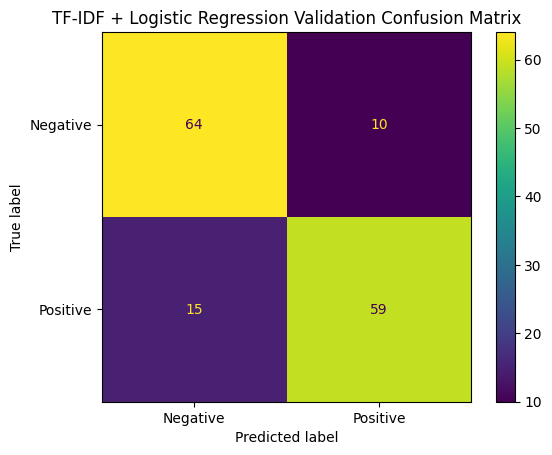

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    logreg_val_predictions,
    display_labels=["Negative", "Positive"]
)

plt.title(
    "TF-IDF + Logistic Regression Validation Confusion Matrix"
)

plt.show()

In [14]:
import mlflow.sklearn

In [15]:
with mlflow.start_run(
    run_name="run_02_tfidf_logreg_unigram"
) as run:

    mlflow.log_param(
        "model",
        "LogisticRegression"
    )

    mlflow.log_param(
        "vectorizer",
        "TfidfVectorizer"
    )

    mlflow.log_param(
        "ngram_range",
        "1_1"
    )

    mlflow.log_param(
        "max_iter",
        1000
    )

    mlflow.log_param(
        "random_state",
        RANDOM_STATE
    )

    mlflow.log_metric(
        "validation_accuracy",
        logreg_accuracy
    )

    mlflow.log_metric(
        "validation_macro_f1",
        logreg_macro_f1
    )

    mlflow.log_metric(
        "runtime_seconds",
        logreg_runtime
    )

    report_dictionary = classification_report(
        y_val,
        logreg_val_predictions,
        target_names=["Negative", "Positive"],
        output_dict=True,
        zero_division=0
    )

    mlflow.log_dict(
        report_dictionary,
        "classification_report.json"
    )

    mlflow.sklearn.log_model(
        sk_model=logreg_pipeline,
        artifact_path="model"
    )

    logreg_run_id = run.info.run_id

print("Logistic Regression run saved.")
print("Run ID:", logreg_run_id)

2026/08/06 05:28:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/06 05:28:45 INFO mlflow.store.db.utils: Updating database tables
2026/08/06 05:28:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logistic Regression run saved.
Run ID: 9351c95b0e714e449ed24e566a55ac5a


In [16]:
comparison_so_far = pd.DataFrame([
    {
        "Run": "Dummy most frequent",
        "Model": "DummyClassifier",
        "Validation Accuracy": dummy_accuracy,
        "Validation Macro F1": dummy_macro_f1,
        "Runtime Seconds": dummy_runtime
    },
    {
        "Run": "TF-IDF unigram Logistic Regression",
        "Model": "Logistic Regression",
        "Validation Accuracy": logreg_accuracy,
        "Validation Macro F1": logreg_macro_f1,
        "Runtime Seconds": logreg_runtime
    }
])

comparison_so_far

,Run,Model,Validation Accuracy,Validation Macro F1,Runtime Seconds
0,Dummy most frequent,DummyClassifier,0.500000,0.333333,0.005805
1,TF-IDF unigram Logistic Regression,Logistic Regression,0.831081,0.830888,0.143187


## Logistic Regression conclusion

The TF-IDF unigram with Logistic Regression model performed much better
than the DummyClassifier baseline.

The DummyClassifier achieved:

- Validation accuracy: 0.5000
- Validation macro F1-score: 0.3333
- Runtime: 0.0058 seconds

The Logistic Regression model achieved:

- Validation accuracy: 0.8311
- Validation macro F1-score: 0.8309
- Runtime: 0.1432 seconds

Logistic Regression improved the validation macro F1-score from 0.3333
to 0.8309. This shows that the model learned useful sentiment patterns
from the review text instead of predicting only one class.

The runtime was slightly longer than the DummyClassifier, but it was still
very fast. The protected test set was not used during this comparison.

## Experiment 3 — TF-IDF + Linear SVM

Linear SVM is a text-classification model that tries to create the clearest
boundary between positive and negative reviews.

This experiment uses the same unigram TF-IDF settings as Logistic Regression,
so the main changed factor is the classifier.

In [17]:
from sklearn.svm import LinearSVC

In [18]:
svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1)
        )
    ),
    (
        "classifier",
        LinearSVC(
            random_state=RANDOM_STATE
        )
    )
])

start_time = time.perf_counter()

svm_pipeline.fit(
    X_train,
    y_train
)

svm_val_predictions = svm_pipeline.predict(
    X_val
)

svm_runtime = time.perf_counter() - start_time

In [19]:
svm_accuracy = accuracy_score(
    y_val,
    svm_val_predictions
)

svm_macro_f1 = f1_score(
    y_val,
    svm_val_predictions,
    average="macro",
    zero_division=0
)

print(
    "Linear SVM validation accuracy:",
    round(svm_accuracy, 4)
)

print(
    "Linear SVM validation macro F1:",
    round(svm_macro_f1, 4)
)

print(
    "Runtime:",
    round(svm_runtime, 4),
    "seconds"
)

Linear SVM validation accuracy: 0.8108
Linear SVM validation macro F1: 0.8108
Runtime: 0.049 seconds


In [20]:
print(
    classification_report(
        y_val,
        svm_val_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.80      0.82      0.81        74
    Positive       0.82      0.80      0.81        74

    accuracy                           0.81       148
   macro avg       0.81      0.81      0.81       148
weighted avg       0.81      0.81      0.81       148



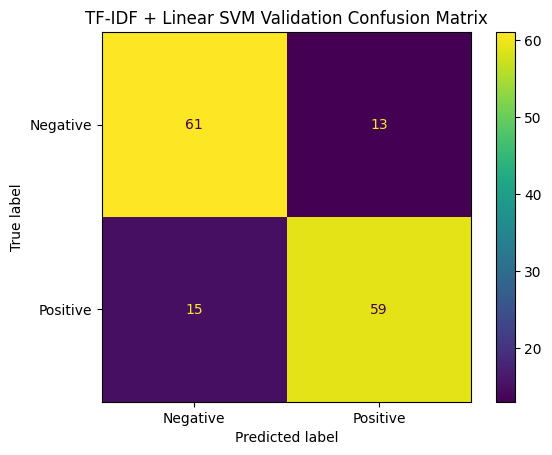

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    svm_val_predictions,
    display_labels=["Negative", "Positive"]
)

plt.title(
    "TF-IDF + Linear SVM Validation Confusion Matrix"
)

plt.show()

In [22]:
with mlflow.start_run(
    run_name="run_03_tfidf_linear_svm_unigram"
) as run:

    mlflow.log_param(
        "model",
        "LinearSVC"
    )

    mlflow.log_param(
        "vectorizer",
        "TfidfVectorizer"
    )

    mlflow.log_param(
        "ngram_range",
        "1_1"
    )

    mlflow.log_param(
        "random_state",
        RANDOM_STATE
    )

    mlflow.log_metric(
        "validation_accuracy",
        svm_accuracy
    )

    mlflow.log_metric(
        "validation_macro_f1",
        svm_macro_f1
    )

    mlflow.log_metric(
        "runtime_seconds",
        svm_runtime
    )

    svm_report = classification_report(
        y_val,
        svm_val_predictions,
        target_names=["Negative", "Positive"],
        output_dict=True,
        zero_division=0
    )

    mlflow.log_dict(
        svm_report,
        "classification_report.json"
    )

    mlflow.sklearn.log_model(
        sk_model=svm_pipeline,
        artifact_path="model"
    )

    svm_run_id = run.info.run_id

print("Linear SVM run saved.")
print("Run ID:", svm_run_id)

2026/08/06 05:33:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear SVM run saved.
Run ID: 223ef3d8a5f9471b97fd9a094deab46d


In [23]:
comparison_three_models = pd.DataFrame([
    {
        "Run": "Dummy most frequent",
        "Model": "DummyClassifier",
        "Validation Accuracy": dummy_accuracy,
        "Validation Macro F1": dummy_macro_f1,
        "Runtime Seconds": dummy_runtime
    },
    {
        "Run": "TF-IDF unigram Logistic Regression",
        "Model": "Logistic Regression",
        "Validation Accuracy": logreg_accuracy,
        "Validation Macro F1": logreg_macro_f1,
        "Runtime Seconds": logreg_runtime
    },
    {
        "Run": "TF-IDF unigram Linear SVM",
        "Model": "Linear SVM",
        "Validation Accuracy": svm_accuracy,
        "Validation Macro F1": svm_macro_f1,
        "Runtime Seconds": svm_runtime
    }
])

comparison_three_models.sort_values(
    "Validation Macro F1",
    ascending=False
)

,Run,Model,Validation Accuracy,Validation Macro F1,Runtime Seconds
1,TF-IDF unigram Logistic Regression,Logistic Regression,0.831081,0.830888,0.143187
2,TF-IDF unigram Linear SVM,Linear SVM,0.810811,0.810776,0.049023
0,Dummy most frequent,DummyClassifier,0.500000,0.333333,0.005805


## Experiment 4 — TF-IDF Unigrams and Bigrams + Logistic Regression

This experiment keeps Logistic Regression unchanged and changes only the
TF-IDF n-gram range from unigrams to unigrams and bigrams.

Hypothesis: Two-word phrases such as "not good", "very useful" and
"waste of" may provide additional sentiment information.

In [24]:
logreg_bigram_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

start_time = time.perf_counter()

logreg_bigram_pipeline.fit(
    X_train,
    y_train
)

logreg_bigram_val_predictions = logreg_bigram_pipeline.predict(
    X_val
)

logreg_bigram_runtime = time.perf_counter() - start_time

In [25]:
logreg_bigram_accuracy = accuracy_score(
    y_val,
    logreg_bigram_val_predictions
)

logreg_bigram_macro_f1 = f1_score(
    y_val,
    logreg_bigram_val_predictions,
    average="macro",
    zero_division=0
)

print(
    "Bigram Logistic Regression validation accuracy:",
    round(logreg_bigram_accuracy, 4)
)

print(
    "Bigram Logistic Regression validation macro F1:",
    round(logreg_bigram_macro_f1, 4)
)

print(
    "Runtime:",
    round(logreg_bigram_runtime, 4),
    "seconds"
)

Bigram Logistic Regression validation accuracy: 0.8514
Bigram Logistic Regression validation macro F1: 0.8512
Runtime: 0.0326 seconds


In [26]:
print(
    classification_report(
        y_val,
        logreg_bigram_val_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.83      0.88      0.86        74
    Positive       0.87      0.82      0.85        74

    accuracy                           0.85       148
   macro avg       0.85      0.85      0.85       148
weighted avg       0.85      0.85      0.85       148



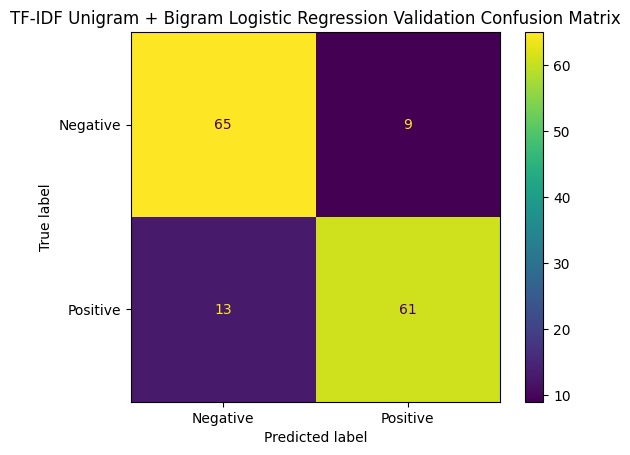

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    logreg_bigram_val_predictions,
    display_labels=["Negative", "Positive"]
)

plt.title(
    "TF-IDF Unigram + Bigram Logistic Regression Validation Confusion Matrix"
)

plt.show()

In [28]:
with mlflow.start_run(
    run_name="run_04_tfidf_logreg_unigram_bigram"
) as run:

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("vectorizer", "TfidfVectorizer")
    mlflow.log_param("ngram_range", "1_2")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("random_state", RANDOM_STATE)

    mlflow.log_metric(
        "validation_accuracy",
        logreg_bigram_accuracy
    )

    mlflow.log_metric(
        "validation_macro_f1",
        logreg_bigram_macro_f1
    )

    mlflow.log_metric(
        "runtime_seconds",
        logreg_bigram_runtime
    )

    bigram_report = classification_report(
        y_val,
        logreg_bigram_val_predictions,
        target_names=["Negative", "Positive"],
        output_dict=True,
        zero_division=0
    )

    mlflow.log_dict(
        bigram_report,
        "classification_report.json"
    )

    mlflow.sklearn.log_model(
        sk_model=logreg_bigram_pipeline,
        artifact_path="model"
    )

    bigram_run_id = run.info.run_id

print("Bigram Logistic Regression run saved.")
print("Run ID:", bigram_run_id)

2026/08/06 05:35:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Bigram Logistic Regression run saved.
Run ID: 937a3c36433b42d8a70035a1f438a945


In [29]:
final_validation_comparison = pd.DataFrame([
    {
        "Run": "Dummy most frequent",
        "Model": "DummyClassifier",
        "TF-IDF": "None",
        "Validation Accuracy": dummy_accuracy,
        "Validation Macro F1": dummy_macro_f1,
        "Runtime Seconds": dummy_runtime
    },
    {
        "Run": "Logistic Regression unigram",
        "Model": "Logistic Regression",
        "TF-IDF": "Unigrams",
        "Validation Accuracy": logreg_accuracy,
        "Validation Macro F1": logreg_macro_f1,
        "Runtime Seconds": logreg_runtime
    },
    {
        "Run": "Linear SVM unigram",
        "Model": "Linear SVM",
        "TF-IDF": "Unigrams",
        "Validation Accuracy": svm_accuracy,
        "Validation Macro F1": svm_macro_f1,
        "Runtime Seconds": svm_runtime
    },
    {
        "Run": "Logistic Regression unigram + bigram",
        "Model": "Logistic Regression",
        "TF-IDF": "Unigrams + bigrams",
        "Validation Accuracy": logreg_bigram_accuracy,
        "Validation Macro F1": logreg_bigram_macro_f1,
        "Runtime Seconds": logreg_bigram_runtime
    }
])

final_validation_comparison.sort_values(
    "Validation Macro F1",
    ascending=False
).reset_index(drop=True)

,Run,Model,TF-IDF,Validation Accuracy,Validation Macro F1,Runtime Seconds
0,Logistic Regression unigram + bigram,Logistic Regression,Unigrams + bigrams,0.851351,0.851243,0.032573
1,Logistic Regression unigram,Logistic Regression,Unigrams,0.831081,0.830888,0.143187
2,Linear SVM unigram,Linear SVM,Unigrams,0.810811,0.810776,0.049023
3,Dummy most frequent,DummyClassifier,None,0.500000,0.333333,0.005805


## Final candidate selection

The TF-IDF unigram and bigram Logistic Regression model achieved the best
validation performance.

Validation results:

- Accuracy: 0.8514
- Macro F1-score: 0.8512
- Runtime: approximately 0.0326 seconds

It outperformed:

- unigram Logistic Regression;
- unigram Linear SVM;
- the DummyClassifier baseline.

The final candidate is therefore the TF-IDF unigram and bigram Logistic
Regression Pipeline.

This decision was made using validation results only. The protected test
set was not used during model selection.

In [30]:
final_pipeline = logreg_bigram_pipeline

FINAL_MODEL_NAME = "TF-IDF unigram_bigram Logistic Regression"

print("Frozen final model:", FINAL_MODEL_NAME)

Frozen final model: TF-IDF unigram_bigram Logistic Regression


In [31]:
final_test_predictions = final_pipeline.predict(X_test)

final_test_accuracy = accuracy_score(
    y_test,
    final_test_predictions
)

final_test_macro_f1 = f1_score(
    y_test,
    final_test_predictions,
    average="macro",
    zero_division=0
)

print(
    "Final test accuracy:",
    round(final_test_accuracy, 4)
)

print(
    "Final test macro F1:",
    round(final_test_macro_f1, 4)
)

Final test accuracy: 0.8054
Final test macro F1: 0.8053


In [32]:
print(
    classification_report(
        y_test,
        final_test_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.80      0.81      0.81        75
    Positive       0.81      0.80      0.80        74

    accuracy                           0.81       149
   macro avg       0.81      0.81      0.81       149
weighted avg       0.81      0.81      0.81       149



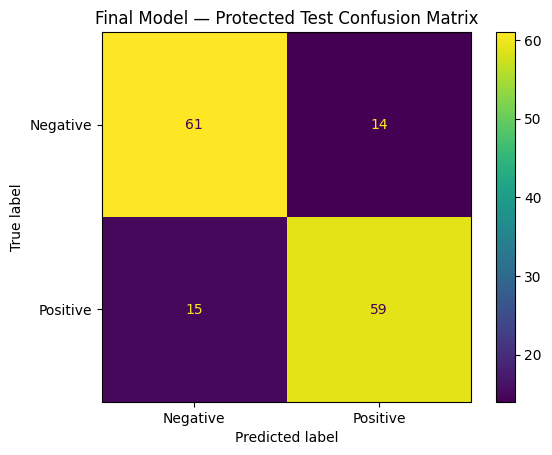

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_predictions,
    display_labels=["Negative", "Positive"]
)

plt.title("Final Model — Protected Test Confusion Matrix")
plt.show()

In [34]:
dummy_test_predictions = dummy_model.predict(
    X_test.to_frame()
)

dummy_test_accuracy = accuracy_score(
    y_test,
    dummy_test_predictions
)

dummy_test_macro_f1 = f1_score(
    y_test,
    dummy_test_predictions,
    average="macro",
    zero_division=0
)

test_comparison = pd.DataFrame([
    {
        "Model": "DummyClassifier",
        "Test Accuracy": dummy_test_accuracy,
        "Test Macro F1": dummy_test_macro_f1
    },
    {
        "Model": FINAL_MODEL_NAME,
        "Test Accuracy": final_test_accuracy,
        "Test Macro F1": final_test_macro_f1
    }
])

test_comparison

,Model,Test Accuracy,Test Macro F1
0,DummyClassifier,0.503356,0.334821
1,TF-IDF unigram_bigram Logistic Regression,0.805369,0.805334


In [35]:
final_test_probabilities = final_pipeline.predict_proba(X_test)

positive_probabilities = final_test_probabilities[:, 1]

error_analysis = pd.DataFrame({
    "review": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "predicted_label": final_test_predictions,
    "positive_probability": positive_probabilities
})

error_analysis["confidence"] = error_analysis[
    "positive_probability"
].apply(
    lambda probability:
    probability if probability >= 0.5
    else 1 - probability
)

error_analysis["error_type"] = "Correct"

error_analysis.loc[
    (error_analysis["true_label"] == 0) &
    (error_analysis["predicted_label"] == 1),
    "error_type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["true_label"] == 1) &
    (error_analysis["predicted_label"] == 0),
    "error_type"
] = "False Negative"

error_analysis.head()

,review,true_label,predicted_label,positive_probability,confidence,error_type
0,AFter the first charge kept going dead after 1...,0,0,0.336114,0.663886,Correct
1,"A week later after I activated it, it suddenly...",0,0,0.363496,0.636504,Correct
2,I ended up sliding it on the edge of my pants ...,1,0,0.422242,0.577758,False Negative
3,"Fits comfortably, came with three sizes of ear...",1,0,0.488803,0.511197,False Negative
4,It looks very nice.,1,1,0.587758,0.587758,Correct


In [36]:
false_positives = error_analysis[
    error_analysis["error_type"] == "False Positive"
].sort_values("confidence", ascending=False)

print("False positives:", len(false_positives))

display(
    false_positives[
        [
            "review",
            "true_label",
            "predicted_label",
            "confidence"
        ]
    ].head(10)
)

False positives: 14


,review,true_label,predicted_label,confidence
101,It defeats the purpose of a bluetooth headset.,0,1,0.607081
23,So just beware.,0,1,0.594649
133,I tried talking real loud but shouting on the ...,0,1,0.569588
31,Disappointing accessory from a good manufacturer.,0,1,0.568502
95,"The internet access was fine, it the rare inst...",0,1,0.543453
93,"When it opens, the battery connection is broke...",0,1,0.536044
110,I've had this bluetoooth headset for some time...,0,1,0.532578
140,"Performed awful -- muffled, tinny incoming sou...",0,1,0.517021
105,worthless product.,0,1,0.516547
86,"The mic there is a joke, and the volume is qui...",0,1,0.503978


In [37]:
false_negatives = error_analysis[
    error_analysis["error_type"] == "False Negative"
].sort_values("confidence", ascending=False)

print("False negatives:", len(false_negatives))

display(
    false_negatives[
        [
            "review",
            "true_label",
            "predicted_label",
            "confidence"
        ]
    ].head(10)
)

False negatives: 15


,review,true_label,predicted_label,confidence
145,I did not have any problem with this item and ...,1,0,0.605082
43,Battery charge-life is quite long.,1,0,0.587096
2,I ended up sliding it on the edge of my pants ...,1,0,0.577758
60,2 thumbs up to this seller,1,0,0.561193
46,I had Verizon 2 years ago and really liked the...,1,0,0.548926
88,I have read other's reviews here but I haven't...,1,0,0.539016
20,"Clear Skype Calls, Long Battery Life, Long Range.",1,0,0.535323
74,* Comes with a strong light that you can use t...,1,0,0.527002
131,Setup went very smoothly.,1,0,0.522723
139,WORTHWHILE.,1,0,0.520911


In [38]:
low_confidence_cases = error_analysis.sort_values(
    "confidence"
)

display(
    low_confidence_cases[
        [
            "review",
            "true_label",
            "predicted_label",
            "confidence",
            "error_type"
        ]
    ].head(10)
)

,review,true_label,predicted_label,confidence,error_type
80,i got this phone around the end of may and i'm...,0,0,0.500146,Correct
64,A usable keyboard actually turns a PDA into a ...,1,1,0.501653,Correct
29,The battery is working well as a replacement f...,1,1,0.502729,Correct
41,The shipping time was also very quick!,1,0,0.502760,False Negative
57,It's so stupid to have to keep buying new char...,0,1,0.502778,False Positive
53,"The camera, although rated at an impressive 1....",0,1,0.502963,False Positive
138,The cutouts and buttons are placed perfectly.,1,1,0.503090,Correct
59,Trying to make a call on these is an exercise ...,0,1,0.503609,False Positive
98,It makes very strange ticking noises before it...,0,1,0.503678,False Positive
86,"The mic there is a joke, and the volume is qui...",0,1,0.503978,False Positive


In [39]:
import os
import json
import joblib

os.makedirs("/content/models", exist_ok=True)
os.makedirs("/content/reports", exist_ok=True)

joblib.dump(
    final_pipeline,
    "/content/models/sentiment_pipeline.joblib"
)

print("Final Pipeline saved.")

Final Pipeline saved.


In [40]:
model_metadata = {
    "project": "RET-02 Product Review Sentiment Intelligence",
    "model": "Logistic Regression",
    "vectorizer": "TF-IDF",
    "ngram_range": [1, 2],
    "random_state": RANDOM_STATE,
    "labels": {
        "0": "Negative",
        "1": "Positive"
    },
    "validation_accuracy": float(logreg_bigram_accuracy),
    "validation_macro_f1": float(logreg_bigram_macro_f1),
    "test_accuracy": float(final_test_accuracy),
    "test_macro_f1": float(final_test_macro_f1)
}

with open(
    "/content/models/model_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_metadata,
        file,
        indent=4
    )

print("Metadata saved.")

Metadata saved.


In [41]:
error_analysis.to_csv(
    "/content/reports/error_analysis.csv",
    index=False
)

test_comparison.to_csv(
    "/content/reports/test_comparison.csv",
    index=False
)

print("Reports saved.")

Reports saved.


In [42]:
reloaded_pipeline = joblib.load(
    "/content/models/sentiment_pipeline.joblib"
)

example_review = "The product is easy to use and works perfectly."

reloaded_prediction = reloaded_pipeline.predict(
    [example_review]
)[0]

reloaded_probability = reloaded_pipeline.predict_proba(
    [example_review]
).max()

label_name = (
    "Positive"
    if reloaded_prediction == 1
    else "Negative"
)

print("Review:", example_review)
print("Prediction:", label_name)
print("Confidence:", round(reloaded_probability, 4))

Review: The product is easy to use and works perfectly.
Prediction: Positive
Confidence: 0.7438


In [44]:
import numpy as np

In [45]:
original_predictions = final_pipeline.predict(
    X_test.head(10)
)

reloaded_predictions = reloaded_pipeline.predict(
    X_test.head(10)
)

print(
    "Reload predictions match:",
    np.array_equal(
        original_predictions,
        reloaded_predictions
    )
)

Reload predictions match: True


In [46]:
print("Final test accuracy:", round(final_test_accuracy, 4))
print("Final test macro F1:", round(final_test_macro_f1, 4))
print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

reload_match = np.array_equal(
    original_predictions,
    reloaded_predictions
)

print("Reload predictions match:", reload_match)

Final test accuracy: 0.8054
Final test macro F1: 0.8053
False positives: 14
False negatives: 15
Reload predictions match: True


## Final test evaluation conclusion

The frozen TF-IDF unigram and bigram Logistic Regression Pipeline was
evaluated once on the protected test set.

Final results:

- Test accuracy: 0.8054
- Test macro F1-score: 0.8053
- False positives: 14
- False negatives: 15

The model clearly outperformed the DummyClassifier baseline, whose macro
F1-score was approximately 0.3333.

The test result was lower than the validation macro F1-score of 0.8512,
which suggests that performance varies slightly on new unseen reviews.
However, the model still demonstrated useful sentiment-classification
ability.

The model made a similar number of false-positive and false-negative errors.
Difficult cases may include short reviews, mixed opinions, informal language,
sarcasm, or words whose meaning depends on context.

The saved Pipeline was reloaded successfully, and its predictions matched
the original Pipeline. Therefore, the complete preprocessing and prediction
flow is reproducible.

No additional tuning was performed after viewing the protected test result.

In [47]:
import os
import shutil

os.makedirs("/content/reports", exist_ok=True)

final_validation_comparison.to_csv(
    "/content/reports/final_validation_comparison.csv",
    index=False
)

mlflow_runs = mlflow.search_runs(
    experiment_names=["RET02_Product_Review_Sentiment"]
)

mlflow_runs.to_csv(
    "/content/reports/mlflow_runs.csv",
    index=False
)

shutil.make_archive(
    "/content/mlruns",
    "zip",
    "/content/mlruns"
)

print("All Model Gate evidence saved.")

2026/08/06 05:46:20 WARNING mlflow.tracking.fluent: Cannot retrieve experiment by name RET02_Product_Review_Sentiment


All Model Gate evidence saved.
